# RAGcore


## 1. .env settings 

In [39]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
load_dotenv(Path("../.env"))


http_proxy = os.getenv("http_proxy")
https_proxy = os.getenv("https_proxy")
HTTP_PROXY = os.getenv("HTTP_PROXY")
HTTPS_PROXY = os.getenv("HTTPS_PROXY")

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.3-70b-versatile")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "sentence-transformers/all-MiniLM-L6-v2")

assert GROQ_API_KEY, "GROQ_API_KEY not found — check that .env exists in the repo root and has a real key."
print("Setup OK")
print(f"  GROQ_MODEL = {GROQ_MODEL}")
print(f"  EMBEDDING_MODEL = {EMBEDDING_MODEL}")

Setup OK
  GROQ_MODEL = llama-3.3-70b-versatile
  EMBEDDING_MODEL = sentence-transformers/all-MiniLM-L6-v2


## 2. Load a document

Extract text from a PDF, page by page

In [77]:
from pypdf import PdfReader

from pathlib import Path

SAMPLE_PDF_PATH = str(Path("../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf"))

reader = PdfReader(SAMPLE_PDF_PATH)
print(f"Loaded {len(reader.pages)} page(s) from {SAMPLE_PDF_PATH}")

pages_text = []
for page_num, page in enumerate(reader.pages, start=1):
    text = page.extract_text() or ""
    if text.strip():
        pages_text.append({"page": page_num, "text": text})

print(f"Extracted text from {len(pages_text)} non-empty page(s)")
print("\n--- Preview of page 1 ---")
print(pages_text[0]["text"][:500])

Loaded 801 page(s) from ../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf
Extracted text from 800 non-empty page(s)

--- Preview of page 1 ---
Deep Learning
Ian Goodfellow
Yoshua Bengio
Aaron Courville


## 3. Chunking

In [78]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = int(os.getenv("CHUNK_SIZE", 1000))
CHUNK_OVERLAP = int(os.getenv("CHUNK_OVERLAP", 150))

page_documents = [
    Document(page_content=p["text"], metadata={"source": SAMPLE_PDF_PATH, "page": p["page"]})
    for p in pages_text
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = splitter.split_documents(page_documents)

for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_index"] = i

print(f"Split {len(page_documents)} page(s) into {len(chunks)} chunk(s)\n")
print(f" No of chunks: {len(chunks)},\n chunk_size={CHUNK_SIZE},\n chunk_overlap={CHUNK_OVERLAP}")
print("\n--- Preview of chunk 0 ---")
print(chunks[0].page_content[:300])
print("\nMetadata:", chunks[0].metadata)

Split 800 page(s) into 2322 chunk(s)

 No of chunks: 2322,
 chunk_size=1000,
 chunk_overlap=150

--- Preview of chunk 0 ---
Deep Learning
Ian Goodfellow
Yoshua Bengio
Aaron Courville

Metadata: {'source': '../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf', 'page': 2, 'chunk_index': 0}


### Visualising chunks stats 


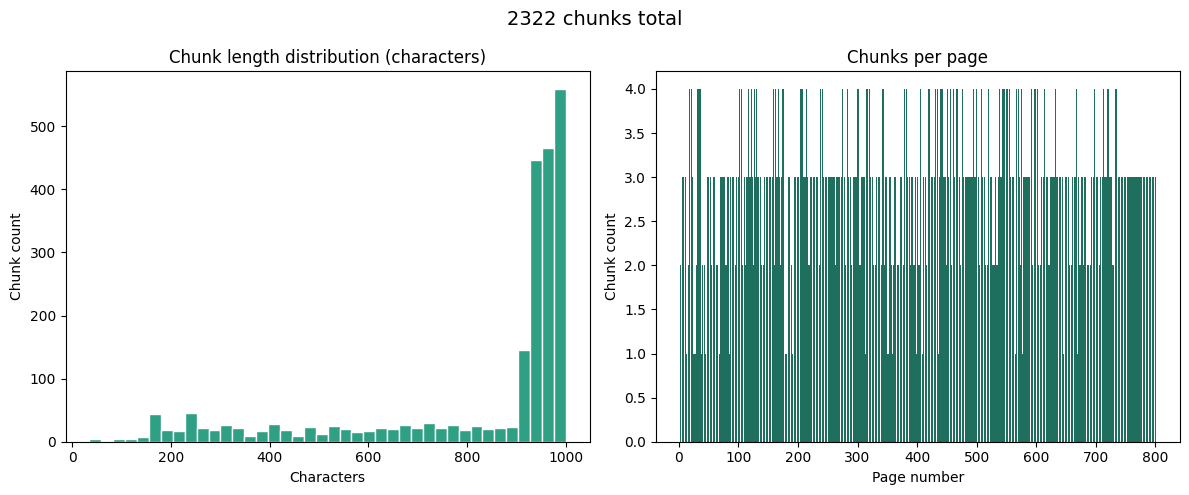

Chunk length — min: 35, max: 1000, avg: 823


In [100]:
import matplotlib.pyplot as plt
from collections import Counter

chunk_lengths = [len(c.page_content) for c in chunks]
chunk_pages = [c.metadata.get("page", 0) for c in chunks]

# Count chunks per page
page_counts = Counter(chunk_pages)
sorted_pages = sorted(page_counts.keys())
counts = [page_counts[p] for p in sorted_pages]

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1. Chunk length histogram
# -------------------------
axes[0].hist(
    chunk_lengths,
    bins=40,
    color="#2fa084",
    edgecolor="white"
)

axes[0].set_title("Chunk length distribution (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Chunk count")

# -------------------------
# 2. Chunks per page
# -------------------------
axes[1].bar(
    sorted_pages,
    counts,
    color="#1f6f5f"
)

axes[1].set_title("Chunks per page")
axes[1].set_xlabel("Page number")
axes[1].set_ylabel("Chunk count")

fig.suptitle(f"{len(chunks)} chunks total", fontsize=14)
plt.tight_layout()
#plt.savefig('chunk_stat.png', dpi = 600)
plt.show()

# Statistics
print(
    f"Chunk length — min: {min(chunk_lengths)}, "
    f"max: {max(chunk_lengths)}, "
    f"avg: {sum(chunk_lengths) / len(chunk_lengths):.0f}"
)

## 4. Embedding

In [ ]:
import os
from langchain_huggingface import HuggingFaceEmbeddings

# HF_HOME default — avoids downloading the model a second time if you've already used it through the running application.
HF_HOME = Path("../.hf_cache").resolve()
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},  # keeps similarity scores well-behaved
)

sample_vector = embedding_model.embed_query(chunks[0].page_content)

print(f"Using HF_HOME")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Vector dimension: {len(sample_vector)}")
print(f"First 8 values: {sample_vector[:8]}")

Using HF_HOME
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Vector dimension: 384
First 8 values: [-0.06303867697715759, -0.016751857474446297, 0.02572939544916153, -0.030512986704707146, -0.08692377060651779, 0.0557619072496891, 0.009984896518290043, -0.06722758710384369]


### what's actually happening under the hood

`HuggingFaceEmbeddings` (via `sentence-transformers`) is already running on PyTorch — it's a convenience wrapper around exactly these steps: tokenize → forward pass through the transformer → pool token vectors into one sentence vector → normalize. Let's do it manually, with raw `transformers` + `torch`, to see the mechanics directly and confirm we get the same result.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F


raw_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)
raw_model = AutoModel.from_pretrained(EMBEDDING_MODEL)
raw_model.eval()  


def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counted = torch.clamp(mask.sum(dim=1), min=1e-9)  
    return summed / counted


def embed_raw_pytorch(text: str) -> torch.Tensor:
    tokens = raw_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad(): 
        output = raw_model(**tokens)
    embedding = mean_pooling(output, tokens["attention_mask"])
    embedding = F.normalize(embedding, p=2, dim=1)  
    return embedding.squeeze()


# Compare against the sentence-transformers wrapper's output for the same text
sample_text = chunks[100].page_content
raw_vector = embed_raw_pytorch(sample_text)
wrapped_vector = embedding_model.embed_query(sample_text)

print(f"Raw PyTorch vector shape: {tuple(raw_vector.shape)}")
print(f"Raw PyTorch first 8 values: {raw_vector[:8].tolist()}")
print(f"\nHuggingFaceEmbeddings first 8 values: {wrapped_vector[:8]}")

similarity = F.cosine_similarity(
    raw_vector.unsqueeze(0),
    torch.tensor(wrapped_vector).unsqueeze(0)
)
print(f"\nCosine similarity between raw-PyTorch and wrapped output: {similarity.item():.6f}")

Raw PyTorch vector shape: (384,)
Raw PyTorch first 8 values: [-0.08621171861886978, -0.0013607284054160118, 0.07335063070058823, -0.019600585103034973, 0.04947417601943016, 0.01534206047654152, 0.008418316021561623, -0.003463044064119458]

HuggingFaceEmbeddings first 8 values: [-0.08621171861886978, -0.0013607284054160118, 0.07335063070058823, -0.019600585103034973, 0.04947417601943016, 0.01534206047654152, 0.008418316021561623, -0.003463044064119458]

Cosine similarity between raw-PyTorch and wrapped output: 1.000000


### Embedding space visualization

Every chunk lives as a 384-dimensional vector — impossible to look at directly. PCA projects them down to 2D while preserving as much of the original variance as possible, so we can actually see how chunks cluster. Coloring by page number often reveals that nearby pages (same topic/chapter) cluster together spatially, even though PCA never saw page numbers — purely a byproduct of semantic similarity.

Embedding 2322 chunks for visualization......


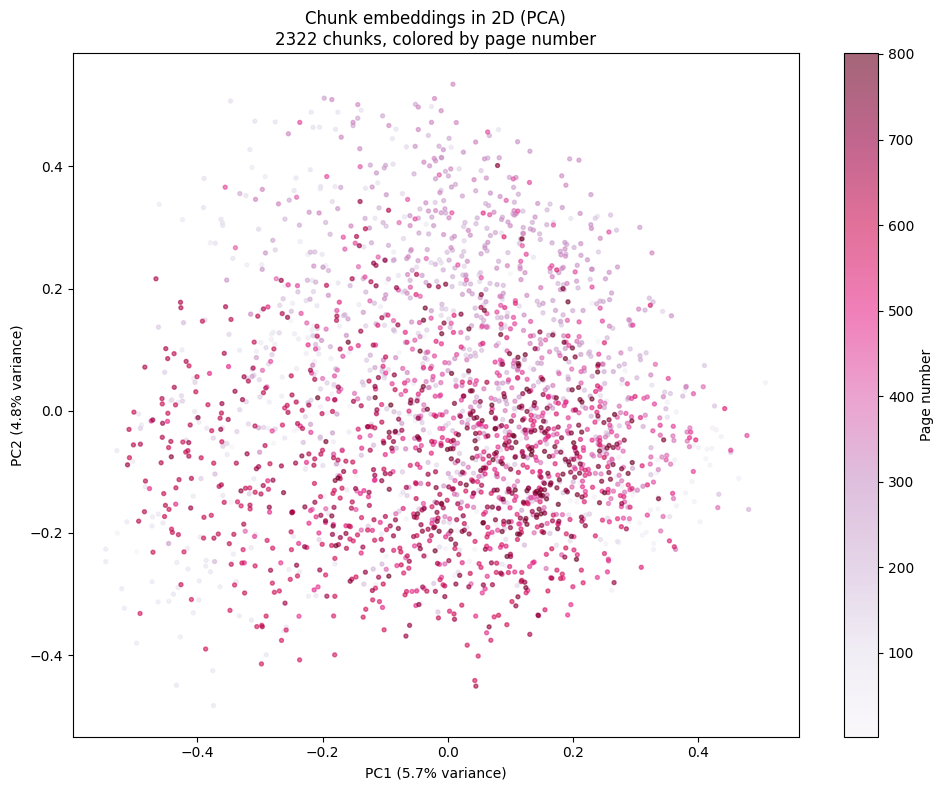

Total variance explained by 2 components: 10.5%


In [101]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print(f"Embedding {len(chunks)} chunks for visualization......")
all_vectors = embedding_model.embed_documents([c.page_content for c in chunks])
all_vectors = np.array(all_vectors)
pages = np.array([c.metadata.get("page", 0) for c in chunks])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_vectors)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=pages, cmap="PuRd", s=8, alpha=0.6
)
plt.colorbar(scatter, label="Page number")
ax.set_title(f"Chunk embeddings in 2D (PCA)\n{len(chunks)} chunks, colored by page number")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
#plt.savefig('2d_PCA.png', dpi = 600)
plt.show()

print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.1%}")

### 3D - PCA

Embedding 2322 chunks for visualization......


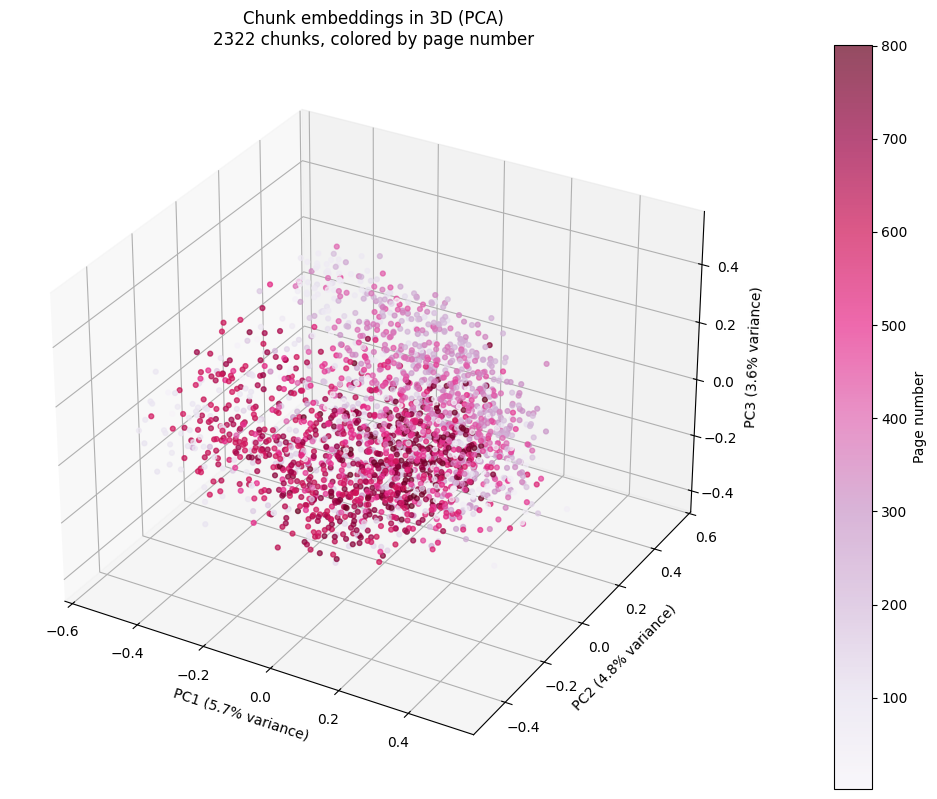

Total variance explained by 3 components: 14.1%


In [102]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print(f"Embedding {len(chunks)} chunks for visualization......")

all_vectors = embedding_model.embed_documents([c.page_content for c in chunks])
all_vectors = np.array(all_vectors)

pages = np.array([c.metadata.get("page", 0) for c in chunks])

# Reduce high-dimensional embeddings to 3 dimensions
pca = PCA(n_components=3)
coords_3d = pca.fit_transform(all_vectors)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    coords_3d[:, 0],   # PC1
    coords_3d[:, 1],   # PC2
    coords_3d[:, 2],   # PC3
    c=pages,
    cmap="PuRd",
    s=12,
    alpha=0.7
)

fig.colorbar(scatter, ax=ax, pad=0.1, label="Page number")

ax.set_title(
    f"Chunk embeddings in 3D (PCA)\n"
    f"{len(chunks)} chunks, colored by page number")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")

ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)")

plt.tight_layout()
#plt.savefig('3d_PCA.png', dpi = 600)
plt.show()

# Total variance explained
total_variance = sum(pca.explained_variance_ratio_)

print(
    f"Total variance explained by 3 components: "
    f"{total_variance:.1%}"
)

### 3D - UMAP

Reducing 2322 embeddings to 3D with UMAP...


/nmhs2/hari/work/UAV/Projects/RAGcore/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


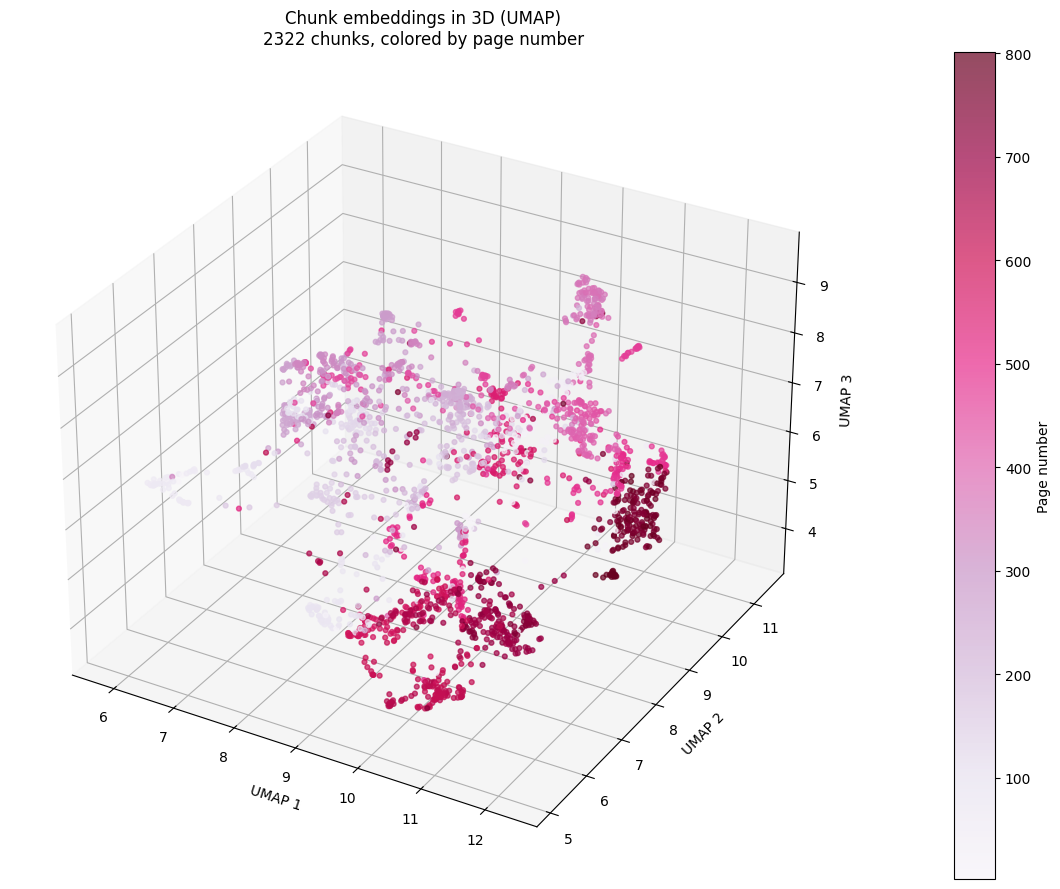

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import umap

print(f"Reducing {len(all_vectors)} embeddings to 3D with UMAP...")

# Reduce embeddings to 3 dimensions
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_3d = reducer.fit_transform(all_vectors)

# Create 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    coords_3d[:, 0],
    coords_3d[:, 1],
    coords_3d[:, 2],
    c=pages,
    cmap="PuRd",
    s=12,
    alpha=0.7
)

# Colorbar
fig.colorbar(scatter,ax=ax,pad=0.1, label="Page number")

ax.set_title(
    f"Chunk embeddings in 3D (UMAP)\n"
    f"{len(chunks)} chunks, colored by page number")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")

plt.tight_layout()
#plt.savefig('3d_UMAP.png', dpi = 600)
plt.show()

## 5. Vector store (Chroma)

Embed all the chunks and store them in a persistent Chroma collection — this is what makes similarity search possible: instead of comparing text directly, we compare the embedding vectors. Uses a separate collection (`notebook_demo`) so this doesn't touch the web app's actual data.

In [ ]:
from langchain_chroma import Chroma

NOTEBOOK_CHROMA_DIR = str(Path("./chroma_demo").resolve())

vectorstore = Chroma(
    collection_name="notebook_demo",
    embedding_function=embedding_model,
    persist_directory=NOTEBOOK_CHROMA_DIR,
)

# Deterministic IDs (chunk_index-based) mean re-running this cell overwrites the same vectors instead of duplicating them.
ids = [f"chunk_{c.metadata['chunk_index']}" for c in chunks]

vectorstore.add_documents(documents=chunks, ids=ids)

print(f"Stored {len(chunks)} chunk(s) in Chroma collection 'notebook_demo'")
print(f"Persisted to Directory")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Stored 2322 chunk(s) in Chroma collection 'notebook_demo'
Persisted to Directory


### Pairwise similarity heatmap

How similar are chunks to each other? A full 2,322×2,322 matrix would be unreadable, so we sample a subset — this reveals blocks of high similarity (likely nearby/related content) versus mostly-dissimilar chunks (unrelated topics).

In [104]:
import numpy as np
import plotly.express as px
from sklearn.metrics.pairwise import cosine_similarity

SAMPLE_SIZE = 40

rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(chroma_data["embeddings"]), size=SAMPLE_SIZE, replace=False)

sample_vectors = np.array(chroma_data["embeddings"])[sample_idx]
sample_pages = [chroma_data["metadatas"][i].get("page", "?") for i in sample_idx]
labels = [f"p.{p}" for p in sample_pages]

sim_matrix = cosine_similarity(sample_vectors)

fig = px.imshow(
    sim_matrix,
    x=labels, y=labels,
    color_continuous_scale="Viridis",
    labels={"color": "Cosine similarity"},
    title=f"Pairwise similarity — random sample of {SAMPLE_SIZE} chunks",
)
fig.update_layout(height=700, width=750)
fig.show()

### Cluster analysis (KMeans)

Group all chunks into K clusters based on embedding similarity — no topic labels given, purely unsupervised. If the document covers genuinely distinct sections/topics, clusters should roughly correspond to them. We plot the clusters in the same 2D PCA space as before, and print a text preview from each cluster to see what it actually grouped together.

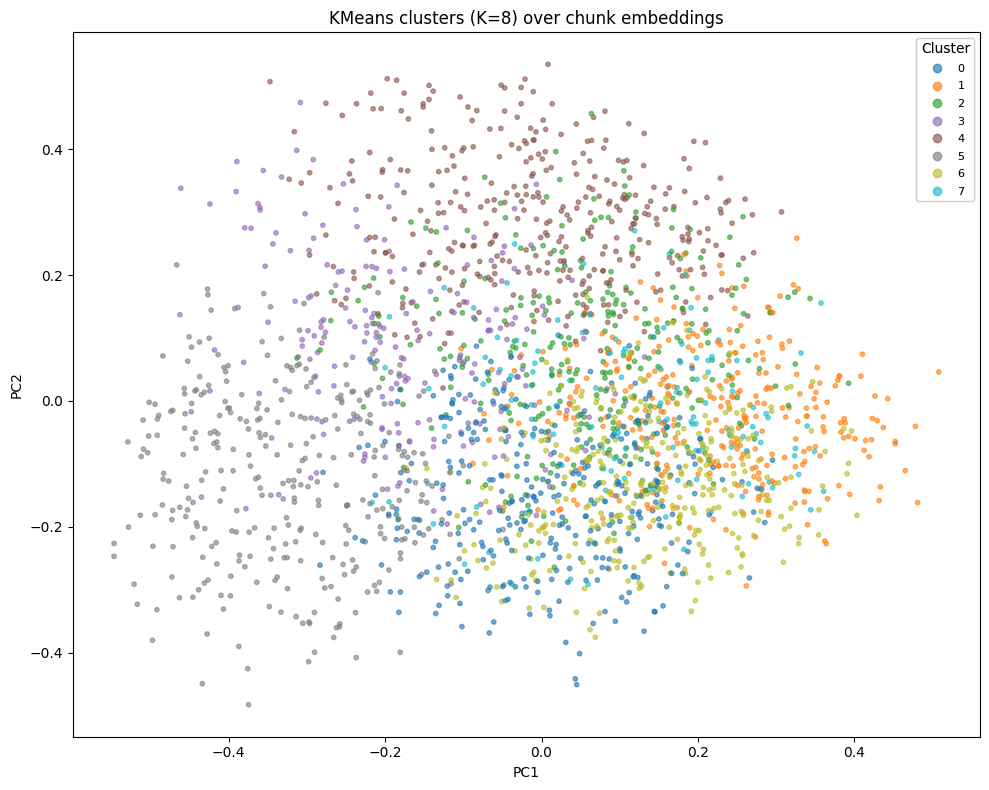

Sample chunk from each cluster:

Cluster 0 (336 chunks): CONTENTS 13.5 Manifold Interpretation of PCA . . . . . . . . . . . . . . . . . . . 499 14 Autoencoders 502 14.1 Undercomplete Autoencoders . . . . . ....

Cluster 1 (320 chunks): Deep Learning Ian Goodfellow Yoshua Bengio Aaron Courville...

Cluster 2 (295 chunks): 5.5 Maximum Likelihood Estimation . . . . . . . . . . . . . . . . . . 131 5.6 Bayesian Statistics . . . . . . . . . . . . . . . . . . . . . . . . . . ...

Cluster 3 (220 chunks): Contents Website vii Acknowledgments viii Notation xi 1 Introduction 1 1.1 Who Should Read This Book? . . . . . . . . . . . . . . . . . . . . 8 1.2 Hi...

Cluster 4 (365 chunks): 3.13 Information Theory . . . . . . . . . . . . . . . . . . . . . . . . . . 73 3.14 Structured Probabilistic Models . . . . . . . . . . . . . . . . . ...

Cluster 5 (326 chunks): CONTENTS 3.2 Random Variables . . . . . . . . . . . . . . . . . . . . . . . . . . 56 3.3 Probability Distributions . . . . . . . . . . . . .

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

N_CLUSTERS = 8

all_vectors = np.array(chroma_data["embeddings"])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_vectors)

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_vectors)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=cluster_labels, cmap="tab10", s=10, alpha=0.6
)
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
ax.add_artist(legend1)
ax.set_title(f"KMeans clusters (K={N_CLUSTERS}) over chunk embeddings")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
#plt.savefig('chunk_embedding_cluster.png', dpi=600)
plt.show()

# Preview one representative chunk per cluster
print("Sample chunk from each cluster:\n")
for cluster_id in range(N_CLUSTERS):
    idx = np.where(cluster_labels == cluster_id)[0][0]
    preview = chroma_data["documents"][idx][:150].replace("\n", " ")
    count = np.sum(cluster_labels == cluster_id)
    print(f"Cluster {cluster_id} ({count} chunks): {preview}...\n")

### Embedding_space (page) and Embedding_space (cluster)

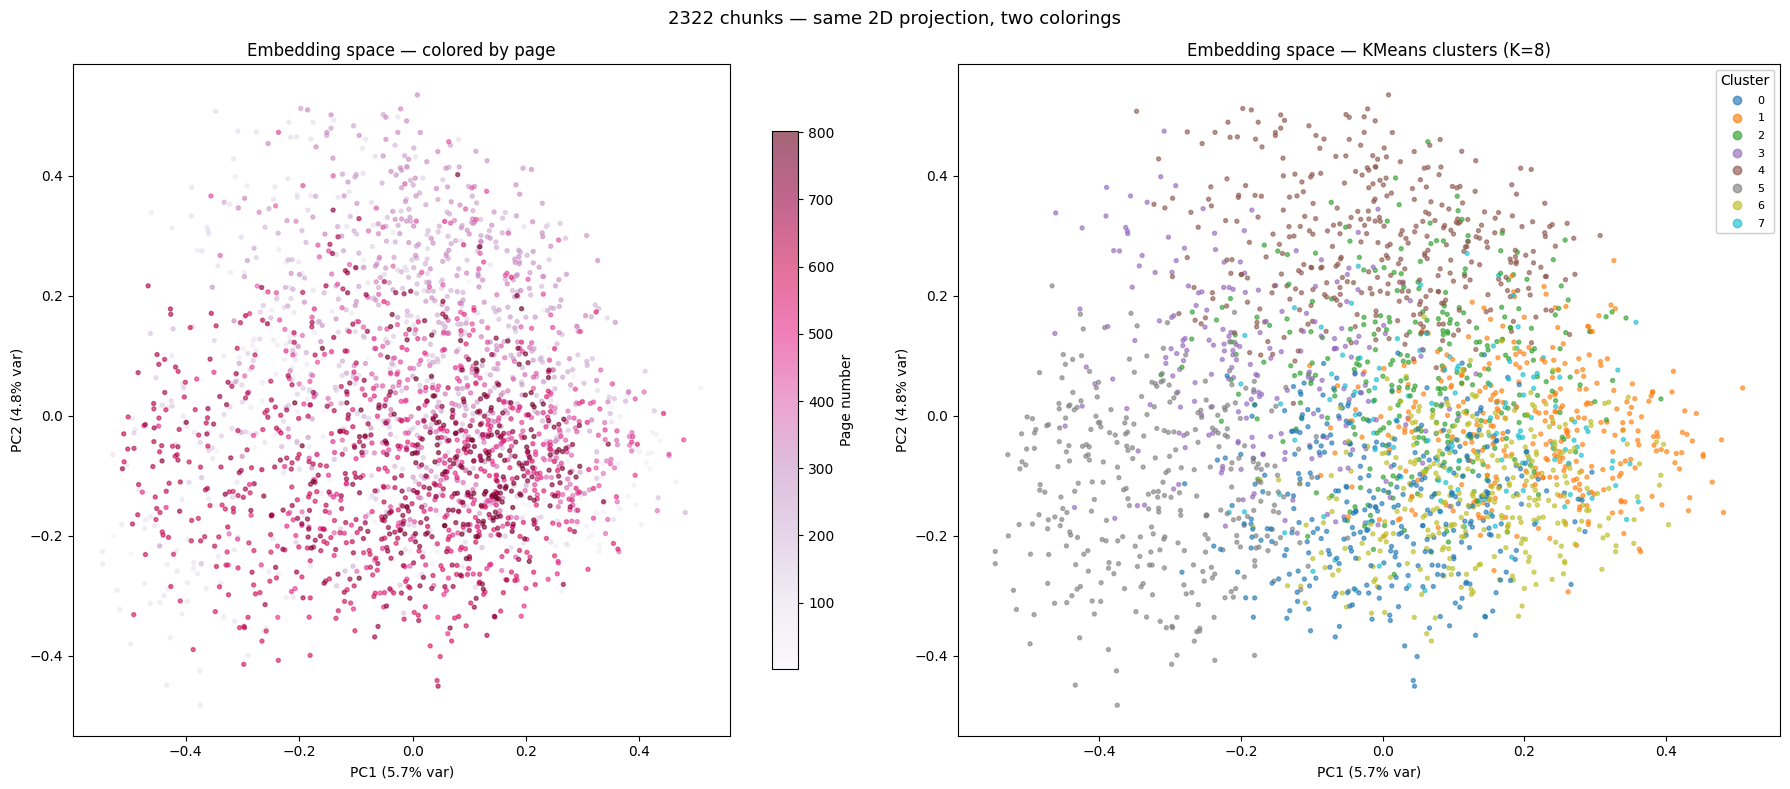

In [116]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

N_CLUSTERS = 8

all_vectors = np.array(chroma_data["embeddings"])
all_pages = [m.get("page", 0) for m in chroma_data["metadatas"]]

# Same 2D projection used for both plots, so they're directly comparable
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_vectors)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: colored by page number ---
sc1 = ax1.scatter(coords_2d[:, 0], coords_2d[:, 1], c=all_pages, cmap="PuRd", s=8, alpha=0.6)
fig.colorbar(sc1, ax=ax1, label="Page number", shrink=0.8)
ax1.set_title("Embedding space — colored by page")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")

# --- Right: colored by KMeans cluster ---
sc2 = ax2.scatter(coords_2d[:, 0], coords_2d[:, 1], c=cluster_labels, cmap="tab10", s=8, alpha=0.6)
legend = ax2.legend(*sc2.legend_elements(), title="Cluster", loc="best", fontsize=8)
ax2.add_artist(legend)
ax2.set_title(f"Embedding space — KMeans clusters (K={N_CLUSTERS})")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")

fig.suptitle(f"{len(all_vectors)} chunks — same 2D projection, two colorings", fontsize=13)
plt.tight_layout()
plt.show()